In [1]:
!apt-get update
!apt-get install -y build-essential zlib1g-dev libbz2-dev liblzma-dev git

!git clone https://github.com/fenderglass/Flye.git
%cd Flye
!python setup.py install

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,011 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,173 kB]
Get:12 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,618 kB]
Get:14 https:/

In [2]:
!flye --version

2.9.6-b1802


In [3]:
from google.colab import files
uploaded = files.upload()

Saving barcode01.fastq.gz to barcode01.fastq.gz
Saving barcode24.fastq.gz to barcode24.fastq.gz
Saving barcode23.fastq.gz to barcode23.fastq.gz
Saving barcode22.fastq.gz to barcode22.fastq.gz
Saving barcode21.fastq.gz to barcode21.fastq.gz
Saving barcode20.fastq.gz to barcode20.fastq.gz
Saving barcode19.fastq.gz to barcode19.fastq.gz
Saving barcode18.fastq.gz to barcode18.fastq.gz
Saving barcode17.fastq.gz to barcode17.fastq.gz
Saving barcode16.fastq.gz to barcode16.fastq.gz
Saving barcode15.fastq.gz to barcode15.fastq.gz
Saving barcode14.fastq.gz to barcode14.fastq.gz
Saving barcode13.fastq.gz to barcode13.fastq.gz
Saving barcode12.fastq.gz to barcode12.fastq.gz
Saving barcode11.fastq.gz to barcode11.fastq.gz
Saving barcode10.fastq.gz to barcode10.fastq.gz
Saving barcode09.fastq.gz to barcode09.fastq.gz
Saving barcode08.fastq.gz to barcode08.fastq.gz
Saving barcode07.fastq.gz to barcode07.fastq.gz
Saving barcode05.fastq.gz to barcode05.fastq.gz
Saving barcode04.fastq.gz to barcode04.f

In [4]:
!ls

barcode01.fastq.gz  barcode11.fastq.gz	barcode20.fastq.gz  flye.egg-info
barcode02.fastq.gz  barcode12.fastq.gz	barcode21.fastq.gz  lib
barcode03.fastq.gz  barcode13.fastq.gz	barcode22.fastq.gz  LICENSE
barcode04.fastq.gz  barcode14.fastq.gz	barcode23.fastq.gz  Makefile
barcode05.fastq.gz  barcode15.fastq.gz	barcode24.fastq.gz  README.md
barcode07.fastq.gz  barcode16.fastq.gz	bin		    requirements.txt
barcode08.fastq.gz  barcode17.fastq.gz	build		    setup.py
barcode09.fastq.gz  barcode18.fastq.gz	docs		    src
barcode10.fastq.gz  barcode19.fastq.gz	flye


In [5]:
import os

os.makedirs("final_assemblies", exist_ok=True)

files = [f for f in os.listdir() if f.endswith(".fastq.gz")]

for f in files:
    name = f.replace(".fastq.gz", "")
    print(f"\n🚀 Running {name}")

    out_dir = f"assembly_{name}"

    # запуск Flye
    !flye --nano-raw {f} --out-dir {out_dir} --threads 2 --meta

    polishing_path = f"{out_dir}/assembly.fasta"
    contig_path = f"{out_dir}/30-contigger/contigs.fasta"

    # зберігаємо polishing
    if os.path.exists(polishing_path):
        out_polish = f"final_assemblies/{name}_assembly.fasta"
        !cp {polishing_path} {out_polish}
        print(f"✅ Saved polished: {out_polish}")

    # зберігаємо contigs
    if os.path.exists(contig_path):
        out_contig = f"final_assemblies/{name}_contigs.fasta"
        !cp {contig_path} {out_contig}
        print(f"📦 Saved contigs: {out_contig}")

    # якщо нічого нема
    if not os.path.exists(polishing_path) and not os.path.exists(contig_path):
        print(f"❌ No assembly for {name}")

    # 🔥 ВИДАЛЯЄМО тимчасову папку
    !rm -rf {out_dir}


🚀 Running barcode07
[2026-03-27 20:04:36] INFO: Starting Flye 2.9.6-b1802
[2026-03-27 20:04:36] INFO: >>>STAGE: configure
[2026-03-27 20:04:36] INFO: Configuring run
[2026-03-27 20:04:36] INFO: Total read length: 328485
[2026-03-27 20:04:36] INFO: Reads N50/N90: 3249 / 2418
[2026-03-27 20:04:36] INFO: Minimum overlap set to 2000
[2026-03-27 20:04:36] INFO: >>>STAGE: assembly
[2026-03-27 20:04:36] INFO: Assembling disjointigs
[2026-03-27 20:04:36] INFO: Reading sequences
[2026-03-27 20:04:42] INFO: Counting k-mers:
0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
[2026-03-27 20:06:28] INFO: Filling index table (1/2)
0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
[2026-03-27 20:06:28] INFO: Filling index table (2/2)
0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
[2026-03-27 20:06:30] INFO: Extending reads
[2026-03-27 20:06:30] INFO: Overlap-based coverage: 2
[2026-03-27 20:06:30] INFO: Median overlap divergence: 0.0340652
0% 10% 20% 40% 70% 100% 
[2026-03-27 20:06:30] INFO: Assembled 5 disjoint

In [6]:
# import os

# files = [f for f in os.listdir() if f.endswith(".fastq.gz")]

# for f in files:
#     name = f.replace(".fastq.gz", "")
#     print(f"Running {name}")
#     !flye --nano-raw {f} --out-dir assembly_{name} --threads 2 --meta

In [7]:
!pip install medaka

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.1/26.1 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 31.5 MB/s eta 0:00:00
  Created wheel for progressbar33: filename=progressbar33-2.4-py3-none-any.whl size=12142 sha256=abc9923b14917651d743159d82867a3cd8b55f8a9eddf87f5a72a8740a35009f
  Stored in directory: /root/.cache/pip/wheels/46/09/ed/4e279d221fcf579bf137464a1f2f92adcbbca797db67996156
Successfully built progressbar33


In [8]:
!medaka tools list_models

Cannot import pyabpoa, some features may not be available.
Available: r103_fast_g507, r103_fast_snp_g507, r103_fast_variant_g507, r103_hac_g507, r103_hac_snp_g507, r103_hac_variant_g507, r103_sup_g507, r103_sup_snp_g507, r103_sup_variant_g507, r1041_e82_260bps_fast_g632, r1041_e82_260bps_fast_variant_g632, r1041_e82_260bps_hac_g632, r1041_e82_260bps_hac_v4.0.0, r1041_e82_260bps_hac_v4.1.0, r1041_e82_260bps_hac_variant_g632, r1041_e82_260bps_hac_variant_v4.1.0, r1041_e82_260bps_joint_apk_ulk_v5.0.0, r1041_e82_260bps_sup_g632, r1041_e82_260bps_sup_v4.0.0, r1041_e82_260bps_sup_v4.1.0, r1041_e82_260bps_sup_variant_g632, r1041_e82_260bps_sup_variant_v4.1.0, r1041_e82_400bps_bacterial_methylation, r1041_e82_400bps_fast_g615, r1041_e82_400bps_fast_g632, r1041_e82_400bps_fast_variant_g615, r1041_e82_400bps_fast_variant_g632, r1041_e82_400bps_hac_g615, r1041_e82_400bps_hac_g632, r1041_e82_400bps_hac_v4.0.0, r1041_e82_400bps_hac_v4.1.0, r1041_e82_400bps_hac_v4.2.0, r1041_e82_400bps_hac_v4.3.0, r

In [9]:
!apt-get update
!apt-get install -y samtools bcftools minimap2 tabix

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 2s (2,577 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installe

In [10]:
import os

os.makedirs("medaka_results", exist_ok=True)

barcodes = ["barcode07", "barcode08", "barcode09", "barcode18"]

for b in barcodes:
    reads = f"{b}.fastq.gz"
    base_dir = f"/content/Flye/assembly_{b}"

    assembly = f"{base_dir}/assembly.fasta"
    contigs = f"{base_dir}/30-contigger/contigs.fasta"
    out_dir = f"medaka_results/{b}"

    print(f"\n🚀 Running Medaka for {b}")

    # вибір файлу
    if os.path.exists(assembly):
        draft = assembly
        print("🧬 using assembly")
    elif os.path.exists(contigs):
        draft = contigs
        print("🧬 using contigs")
    else:
        print(f"❌ No assembly/contigs for {b}")
        continue

    if not os.path.exists(reads):
        print(f"❌ Missing reads: {reads}")
        continue

    !medaka_consensus \
        -i {reads} \
        -d {draft} \
        -o {out_dir} \
        -t 2 \
        -m r1041_e82_400bps_sup_v5.2.0


🚀 Running Medaka for barcode07
❌ No assembly/contigs for barcode07

🚀 Running Medaka for barcode08
❌ No assembly/contigs for barcode08

🚀 Running Medaka for barcode09
❌ No assembly/contigs for barcode09

🚀 Running Medaka for barcode18
❌ No assembly/contigs for barcode18


In [11]:
import os

os.makedirs("medaka_results", exist_ok=True)

barcodes = ["barcode07", "barcode08", "barcode09", "barcode18"]

for b in barcodes:
    reads = f"{b}.fastq.gz"
    assembly = f"Assembly/{b}_assembly.fasta"
    out_dir = f"medaka_results/{b}"

    print(f"\n🚀 Running Medaka for {b}")

    !medaka_consensus \
    -i {reads} \
    -d {assembly} \
    -o {out_dir} \
    -t 2 \
    -m r1041_e82_400bps_sup_v5.2.0


🚀 Running Medaka for barcode07
Cannot import pyabpoa, some features may not be available.
Cannot import pyabpoa, some features may not be available.
Cannot import pyabpoa, some features may not be available.
Checking program versions
This is medaka 2.2.0
Cannot import pyabpoa, some features may not be available.
Program    Version    Required   Pass     
bcftools   1.13       1.11       True     
bgzip      1.13+ds    1.11       True     
minimap2   2.24       2.11       True     
samtools   1.13       1.11       True     
tabix      1.13+ds    1.11       True     
Cannot import pyabpoa, some features may not be available.
[20:48:52 - MdlStrTGZ] Successfully removed temporary files from /tmp/tmpw4_0_jdf.
Cannot import pyabpoa, some features may not be available.
[20:48:56 - MdlStrTGZ] Successfully removed temporary files from /tmp/tmp6aumtc10.
Cannot import pyabpoa, some features may not be available.
[20:49:01 - MdlStrTGZ] Successfully removed temporary files from /tmp/tmprcwf7lre.
[

In [12]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


In [13]:
!conda install -c bioconda ncbi-amrfinderplus -y

Channels:
 - bioconda
 - conda-forge
Platform: linux-64
Solving environment: - \ | / done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - ncbi-amrfinderplus


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    blast-2.16.0               |       h66d330f_4       141.4 MB  bioconda
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    curl-8.18.0                |       h4e3cde8_0         186 KB  conda-forge
    entrez-direct-22.4         |       he881be0_0        14.0 MB  bioconda
    gsl-2.7                    |       he838d99_0         3.2 MB  conda-forge
    hmmer-3.4                  

In [1]:
!which amrfinder

/usr/local/bin/amrfinder


In [2]:
!amrfinder -u

Running: amrfinder -u
The number of threads cannot be greater than 2 on this computer
The current number of threads is 4, reducing to 2
Software directory: /usr/local/bin/
Software version: 4.2.7
Reverting to hard coded directory: /usr/local/share/amrfinderplus/data/latest
Running: /usr/local/bin/amrfinder_update -d /usr/local/share/amrfinderplus/data
Looking up the published databases at https://ftp.ncbi.nlm.nih.gov/pathogen/Antimicrobial_resistance/AMRFinderPlus/database/
Looking for the target directory: /usr/local/share/amrfinderplus/data/2026-03-24.1/
Running: /usr/local/bin/amrfinder_index /usr/local/share/amrfinderplus/data/2026-03-24.1/
Indexing
amrfinder_index took 6 seconds to complete
amrfinder_update took 9 seconds to complete
Database directory: /usr/local/share/amrfinderplus/data/2026-03-24.1
Database version: 2026-03-24.1
amrfinder took 9 seconds to complete


In [4]:
from google.colab import files
uploaded = files.upload()

Saving barcode18_consensus.fasta to barcode18_consensus.fasta
Saving barcode09_consensus.fasta to barcode09_consensus.fasta
Saving barcode08_consensus.fasta to barcode08_consensus.fasta
Saving barcode07_consensus.fasta to barcode07_consensus.fasta


In [5]:
import os

barcodes = ["07", "08", "09", "18"]

for i in barcodes:
    os.system(f"amrfinder -n barcode{i}_consensus.fasta -o result_barcode{i}.tsv")

In [ ]:
!ls result_*.tsv

In [6]:
import pandas as pd
import glob

files = glob.glob("result_barcode*.tsv")

dfs = []

for f in files:
    df = pd.read_csv(f, sep="\t")
    barcode = f.split("_")[-1].replace(".tsv", "")
    df["barcode"] = barcode
    dfs.append(df)

all_data = pd.concat(dfs)

all_data.head()

/tmp/ipykernel_34688/3197321019.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_data = pd.concat(dfs)


,Protein id,Contig id,Start,Stop,Strand,Element symbol,Element name,Scope,Type,Subtype,...,Target length,Reference sequence length,% Coverage of reference,% Identity to reference,Alignment length,Closest reference accession,Closest reference name,HMM accession,HMM description,barcode
0,NaN,contig_4,2146,2682,+,qnrD,QnrD family quinolone resistance pentapeptide ...,core,AMR,AMR,...,179,214,83.64,100.0,179,WP_012634451.1,quinolone resistance pentapeptide repeat prote...,NaN,NaN,barcode09
0,NaN,contig_2,1660,2301,-,qnrD1,quinolone resistance pentapeptide repeat prote...,core,AMR,AMR,...,214,214,100.00,100.0,214,WP_012634451.1,quinolone resistance pentapeptide repeat prote...,NaN,NaN,barcode07
0,NaN,contig_20,919,1560,+,qnrD1,quinolone resistance pentapeptide repeat prote...,core,AMR,AMR,...,214,214,100.00,100.0,214,WP_012634451.1,quinolone resistance pentapeptide repeat prote...,NaN,NaN,barcode18


In [7]:
!cat result_barcode18.tsv

Protein id	Contig id	Start	Stop	Strand	Element symbol	Element name	Scope	Type	Subtype	Class	Subclass	Method	Target length	Reference sequence length	% Coverage of reference	% Identity to reference	Alignment length	Closest reference accession	Closest reference name	HMM accession	HMM description
NA	contig_20	919	1560	+	qnrD1	quinolone resistance pentapeptide repeat protein QnrD1	core	AMR	AMR	QUINOLONE	QUINOLONE	ALLELEX	214	214	100.00	100.00	214	WP_012634451.1	quinolone resistance pentapeptide repeat protein QnrD1	NA	NA


In [8]:
pivot = all_data.pivot_table(
    index="barcode",
    columns="Class",
    aggfunc="size",
    fill_value=0
)

pivot

Class,QUINOLONE
barcode,
barcode07,1
barcode09,1
barcode18,1


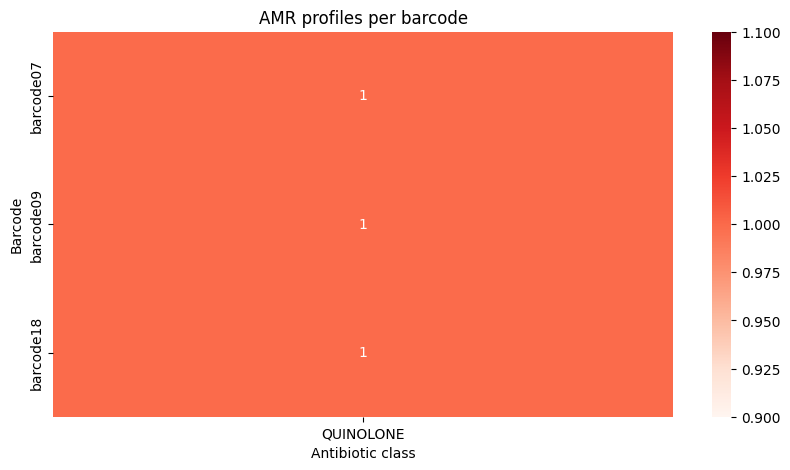

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, cmap="Reds")

plt.title("AMR profiles per barcode")
plt.xlabel("Antibiotic class")
plt.ylabel("Barcode")

plt.show()